In [1]:
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
import joblib

In [2]:
import warnings
warnings.simplefilter(action='ignore', category=Warning)

For reproducibility of results:

In [3]:
random.seed(42)
np.random.seed(42)

# 1. First look at the data

In [4]:
df = pd.read_csv('/kaggle/input/datasets/mrdaniilak/russia-real-estate-2021/input_data.csv',
                 sep=';')

df.head()

,date,price,level,levels,rooms,area,kitchen_area,geo_lat,geo_lon,building_type,object_type,postal_code,street_id,id_region,house_id
0,2021-01-01,2451300,15,31,1,30.3,0.0,56.780112,60.699355,0,2,620000.0,NaN,66,1632918.0
1,2021-01-01,1450000,5,5,1,33.0,6.0,44.608154,40.138381,0,0,385000.0,NaN,1,NaN
2,2021-01-01,10700000,4,13,3,85.0,12.0,55.540060,37.725112,3,0,142701.0,242543.0,50,681306.0
3,2021-01-01,3100000,3,5,3,82.0,9.0,44.608154,40.138381,0,0,385000.0,NaN,1,NaN
4,2021-01-01,2500000,2,3,1,30.0,9.0,44.738685,37.713668,3,2,353960.0,439378.0,23,1730985.0


The features are numerical and categorical:

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11358150 entries, 0 to 11358149
Data columns (total 15 columns):
 #   Column         Dtype  
---  ------         -----  
 0   date           object 
 1   price          int64  
 2   level          int64  
 3   levels         int64  
 4   rooms          int64  
 5   area           float64
 6   kitchen_area   float64
 7   geo_lat        float64
 8   geo_lon        float64
 9   building_type  int64  
 10  object_type    int64  
 11  postal_code    float64
 12  street_id      float64
 13  id_region      int64  
 14  house_id       float64
dtypes: float64(7), int64(7), object(1)
memory usage: 1.3+ GB


The dataset is huge.

We see some negative values in the descriptive statistics, which is odd (for example, the negative mean for 'kitchen_area'). This needs to be investigated in the future.

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
price,11358150.0,6.787516e+06,1.977118e+08,0.000000,2.600000e+06,3.995000e+06,6.500000e+06,6.355524e+11
level,11358150.0,6.426675e+00,5.283144e+00,0.000000,2.000000e+00,5.000000e+00,9.000000e+00,5.000000e+01
levels,11358150.0,1.176266e+01,7.218441e+00,0.000000,5.000000e+00,1.000000e+01,1.700000e+01,5.000000e+01
rooms,11358150.0,1.719417e+00,1.157606e+00,-1.000000,1.000000e+00,2.000000e+00,2.000000e+00,9.000000e+00
area,11358150.0,5.310356e+01,2.712845e+01,1.000000,3.650000e+01,4.670000e+01,6.300000e+01,4.999000e+02
kitchen_area,11358150.0,-2.674071e+00,3.241855e+01,-100.000000,0.000000e+00,6.500000e+00,1.050000e+01,4.080000e+02
geo_lat,11358150.0,5.440394e+01,4.582962e+00,41.437585,5.319411e+01,5.564688e+01,5.687362e+01,7.350889e+01
geo_lon,11358150.0,5.229570e+01,2.183899e+01,-173.218911,3.763847e+01,4.202111e+01,6.547322e+01,1.792583e+02
building_type,11358150.0,1.017820e+00,1.562077e+00,0.000000,0.000000e+00,0.000000e+00,2.000000e+00,6.000000e+00
object_type,11358150.0,5.275366e-01,8.813503e-01,0.000000,0.000000e+00,0.000000e+00,2.000000e+00,2.000000e+00


The data contains NaN values:

In [7]:
df.isnull().sum()

date                   0
price                  0
level                  0
levels                 0
rooms                  0
area                   0
kitchen_area           0
geo_lat                0
geo_lon                0
building_type          0
object_type            0
postal_code       507771
street_id        4205554
id_region              0
house_id         3261943
dtype: int64

Data contains duplicates (because of the way of collecting data):

In [8]:
df.duplicated(keep='first').sum()

np.int64(396685)

# 2. EDA and primary data processing

We can remove the next features:

- 'date' - the ad's publication date. This might be useful, but we'll remove it.

- 'geo_lat' - latitude. This can be used for complex analysis, but 'id_region' will be sufficient for determining location.

- 'geo_lon' - longitude. Ditto.

- 'postal_code'. Ditto.

- 'street_id'. Ditto.

- 'house_id'. Ditto. 

In [9]:
df = df.drop(columns=['date', 'geo_lat', 'geo_lon', 'postal_code',
                      'street_id', 'house_id'])

df.head()

,price,level,levels,rooms,area,kitchen_area,building_type,object_type,id_region
0,2451300,15,31,1,30.3,0.0,0,2,66
1,1450000,5,5,1,33.0,6.0,0,0,1
2,10700000,4,13,3,85.0,12.0,3,0,50
3,3100000,3,5,3,82.0,9.0,0,0,1
4,2500000,2,3,1,30.0,9.0,3,2,23


Duplicates should be removed:

In [10]:
df = df.drop_duplicates(keep='first')

df.duplicated(keep='first').sum()

np.int64(0)

Let's take a look on target variable distribution. It is heavily skewed to the right:

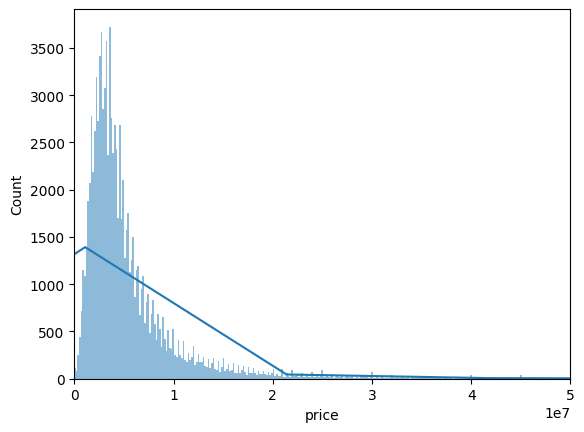

In [11]:
# to plot the graphs we will use a sample (large data frame)
df_sample = df.sample(10 ** 5, replace=False)

# to speed up the process, we can convert our data into a more lightweight format
sns.histplot(df_sample['price'].astype('int32'), kde=True);
# distribution is heavily skewed to the right, so we'll limit the range
plt.xlim(0, 5 * 10 ** 7);

**2.1 Categorical features**

In [12]:
cat_features = df.select_dtypes(include='object').columns.tolist()

cat_features

[]

There are no categorical features by type, but some features are categorical in essence.

In [13]:
cat_features = ['building_type', 'object_type', 'id_region']
df_cat = df[cat_features]

df_cat.head()

,building_type,object_type,id_region
0,0,2,66
1,0,0,1
2,3,0,50
3,0,0,1
4,3,2,23


Let's plot graphs for categorical features. We need to add target variable:

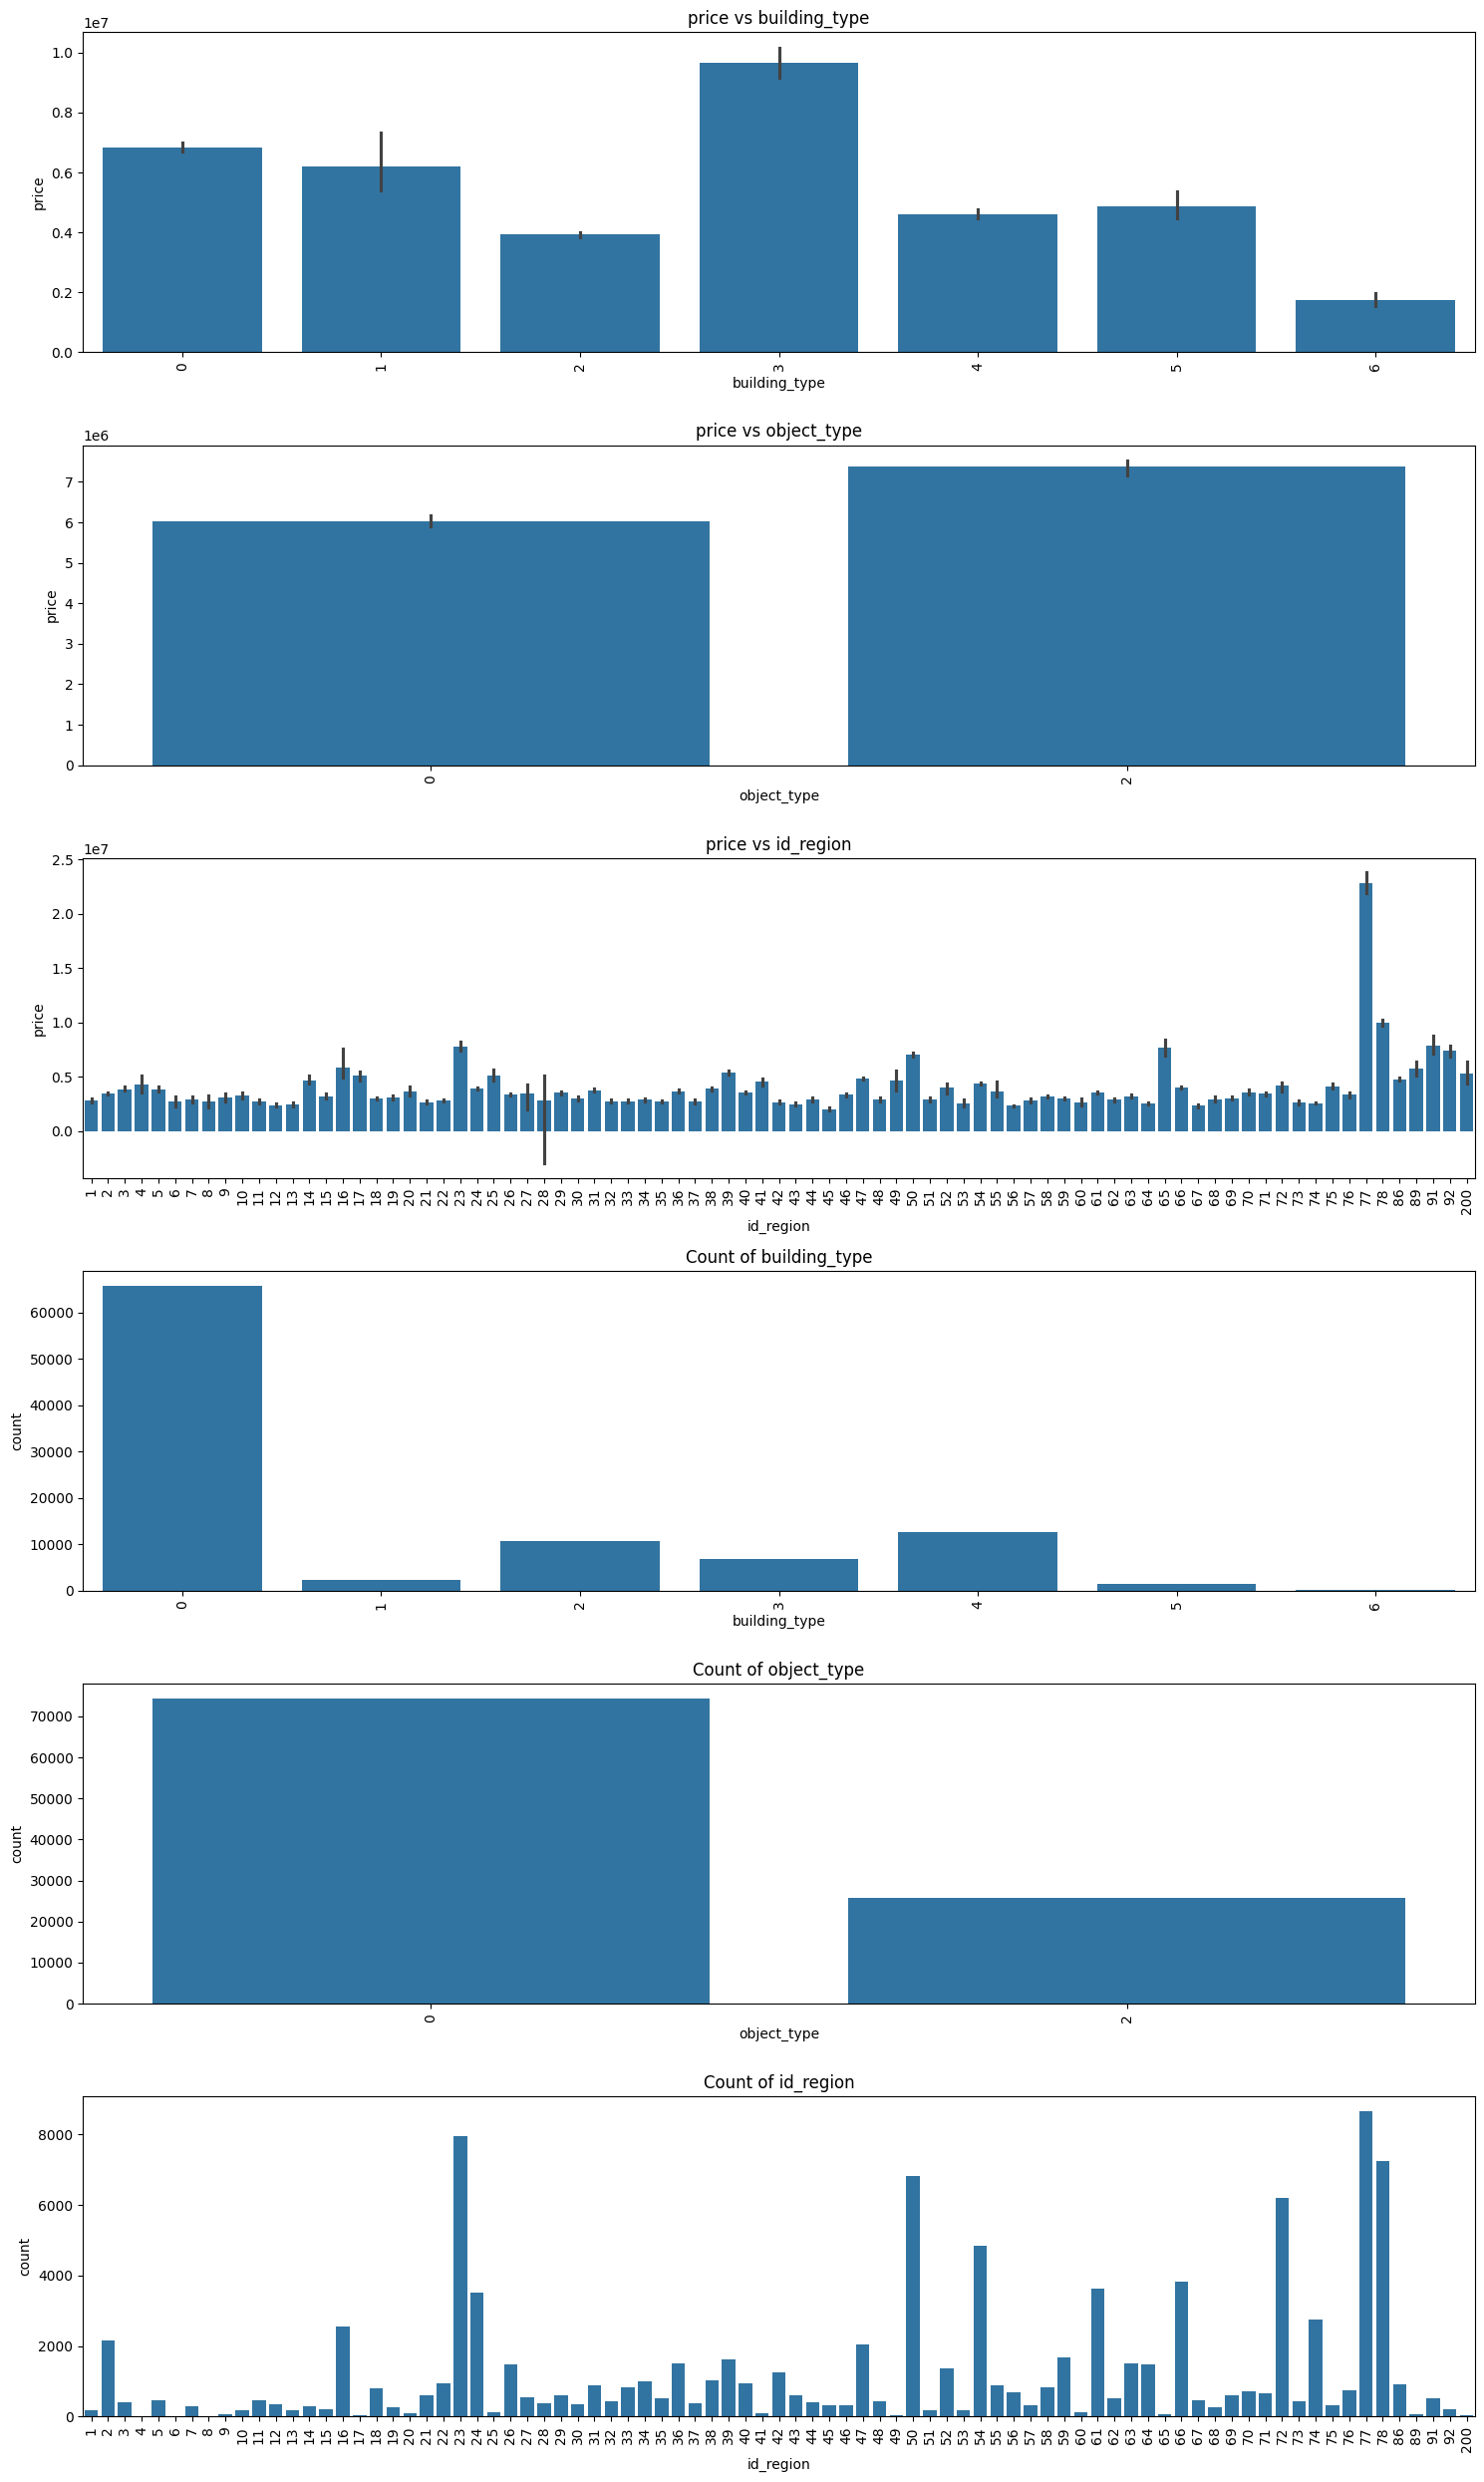

In [14]:
df_cat_target = df_cat.join(df['price'])

def cat_features_vis(df):
    # we're taking sample in df
    df = df.sample(10 ** 5, replace=False)
    
    fig, ax = plt.subplots(6, 1, figsize=(15, 25))
    ax = ax.flatten()

    for i, col in enumerate(df.drop(columns='price').columns):
        # our cat_features have dtype 'int64', so we can convert them to 'int16'
        p = sns.barplot(x=df[col].astype('int16'), y=df['price'].astype('int32'), ax=ax[i], estimator='mean');
        p.set_xticklabels(p.get_xticklabels(), rotation=90); # turning ticks of axis for ax
        ax[i].set_title(f'price vs {col}')

        g = sns.countplot(x=df[col].astype('int16'), ax=ax[i + 3]);
        g.set_xticklabels(p.get_xticklabels(), rotation=90); # turning ticks of axis for ax
        ax[i + 3].set_title(f'Count of {col}')

    plt.tight_layout()


cat_features_vis(df_cat_target)

Information about some features:

- 'building_type': 0 - don't know; 1 - other; 2 - panel; 3 - monolithic; 4 - brick; 5 - blocky; 6 - wooden;
- 'object_type': 0 - secondary real estate market; 2 - new building;
- the number of rooms can also be as 1, 2 or more. However, there is a type of apartment that is called a studio apartment. They are labeled '-1'.

Let's create a Series with number of unique values of all categorical features:

In [15]:
unique_values = pd.Series(index=cat_features, name='unique_values')
for i, col in enumerate(df_cat.columns):
    unique_values[i] = df_cat[col].nunique()

unique_values

building_type     7.0
object_type       2.0
id_region        86.0
Name: unique_values, dtype: float64

**Our data has high cardinality because of 'id_region'.**

**We can apply OrdinalEncoder for all categorical features, because there are not ordinal features.**

**2.2 Numerical features**

Let's choose numerical features:

In [16]:
num_features = set(df.select_dtypes(include='number').columns.tolist()) - set(cat_features)
num_features = list(num_features)
df_num = df[num_features]

num_features

['levels', 'area', 'price', 'rooms', 'kitchen_area', 'level']

In [17]:
df_num.head()

,levels,area,price,rooms,kitchen_area,level
0,31,30.3,2451300,1,0.0,15
1,5,33.0,1450000,1,6.0,5
2,13,85.0,10700000,3,12.0,4
3,5,82.0,3100000,3,9.0,3
4,3,30.0,2500000,1,9.0,2


Let's estimate correlation between numerical features:

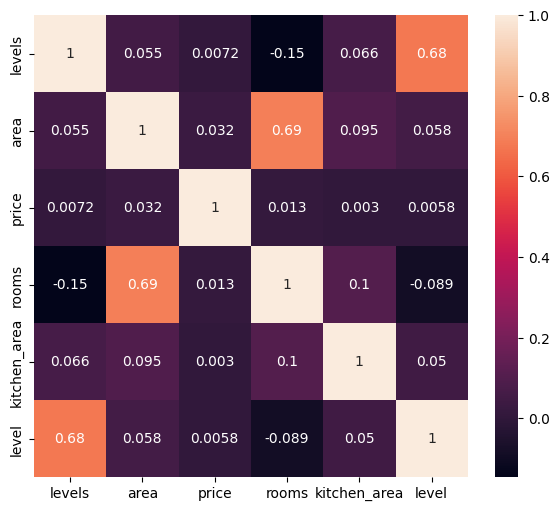

In [18]:
plt.figure(figsize=(7, 6))
sns.heatmap(df_num.corr(), annot=True);

There are no features that have a high correlation with price.

Oddly enough, price has virtually no correlation with square. This is partly due to the fact that prices vary greatly across different regions.

For example, if we select data for only one region (Moscow), the values will be different:

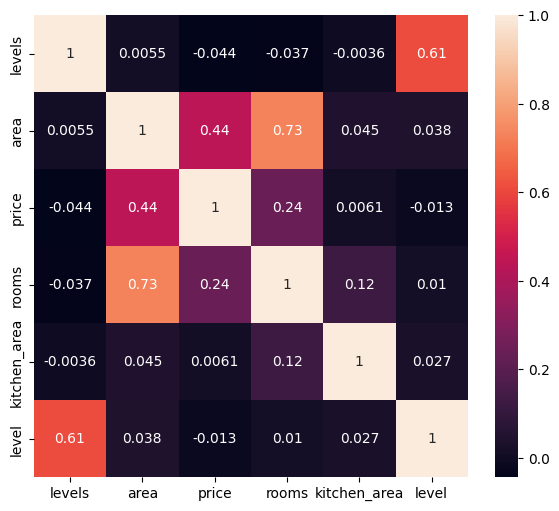

In [19]:
df_moscow = df[df['id_region'] == 77]

plt.figure(figsize=(7, 6))
sns.heatmap(df_moscow[num_features].corr(), annot=True);

Let's plot graphs for numerical features.

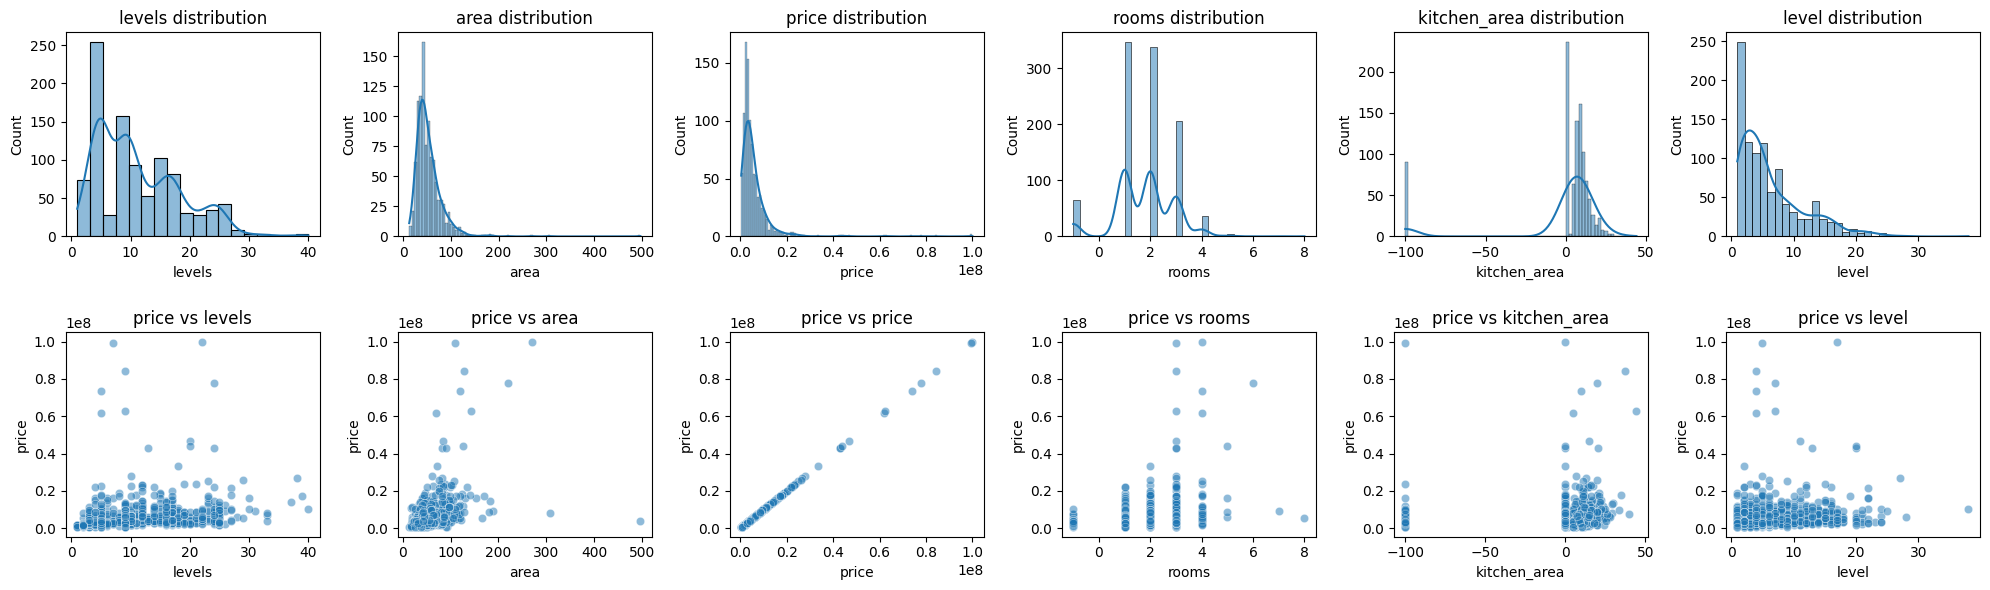

In [20]:
def num_features_vis(df):
    # we're taking sample in df
    df = df.sample(1000, replace=False)
    
    fig, ax = plt.subplots(2, 6, figsize=(20, 6))
    ax = ax.flatten()

    for i, col in enumerate(df.columns):
        sns.histplot(df[col].astype('int32'), kde=True, ax=ax[i]);
        ax[i].set_title(f'{col} distribution')

        sns.scatterplot(x=df[col], y=df['price'].astype('int32'), alpha=0.5, ax=ax[i + 6]);
        ax[i + 6].set_title(f'price vs {col}')

    plt.tight_layout()


num_features_vis(df_num)

We see the following anomalies in these graphs:

- there is a type of apartment that is called a studio apartment. They are labeled '-1'. We'll fix it.
- 'kitchen_area' contains negative values. We need to fix this.

And we can make boxplot graphs for relation between numerical and categorical features and for outliers detection:

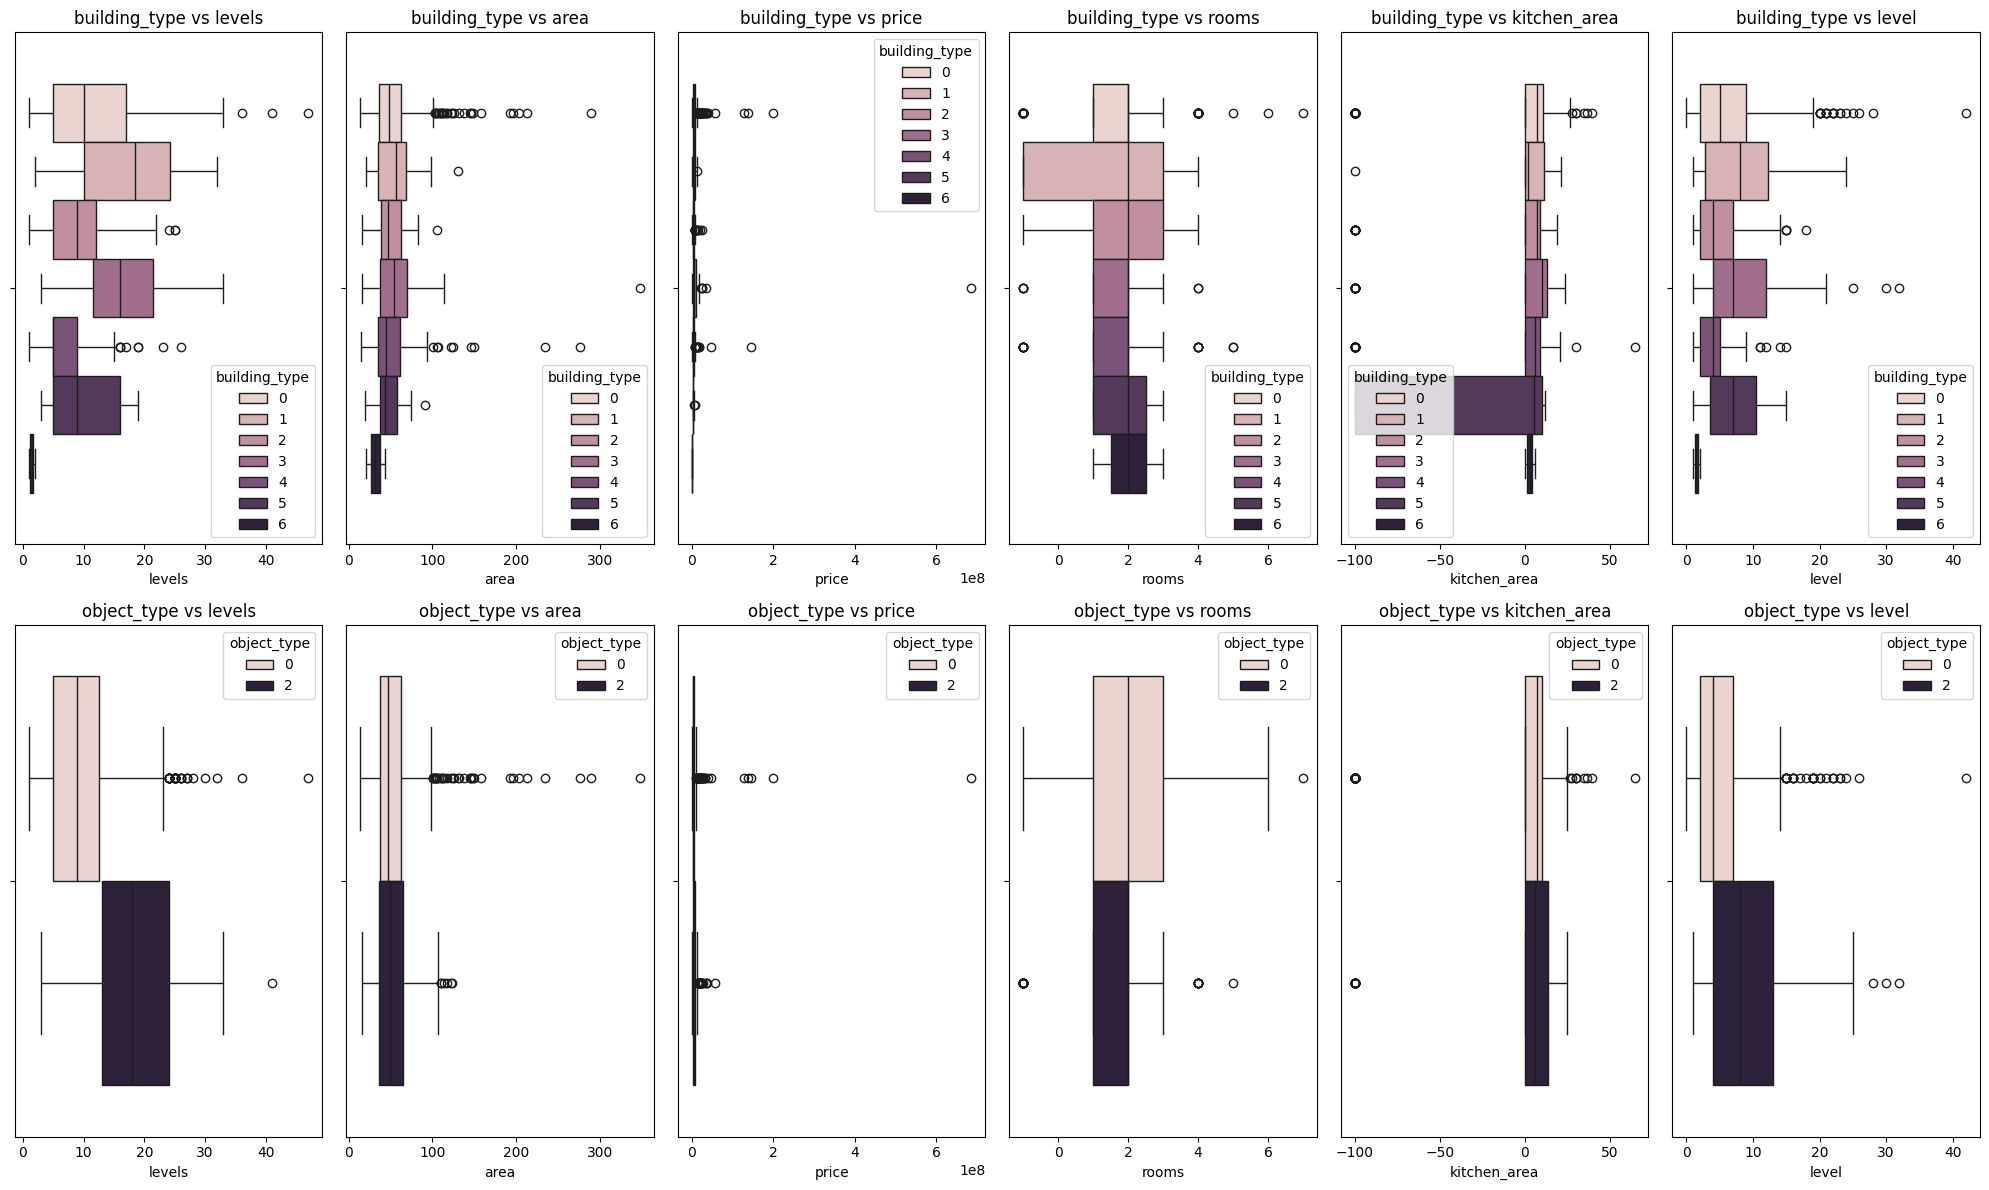

In [21]:
def outliers_vis(df):
    fig, ax = plt.subplots(2, 6, figsize=(20, 12))
    # we're taking sample
    idx = np.random.randint(0, len(df), size=1000)
    df_num_sample = df.iloc[idx]
    # remove 'id_region' because of high cardinality 
    df_cat_sample = df_cat.iloc[idx].drop(columns='id_region')

    for i, col_cat in enumerate(df_cat_sample.columns):
        for j, col_num in enumerate(df_num_sample.columns):
            sns.boxplot(x=df_num_sample[col_num], hue=df_cat_sample[col_cat], ax=ax[i, j])
            ax[i, j].set_title(f'{col_cat} vs {col_num}')

    plt.tight_layout()


outliers_vis(df_num)

Boxplots show that data contains outliers. We will consider this issue in more detail in chapter 3.

**Takeaways**

**We have few features, all they will be used. We can create a new features also.**

**2.3 Creating an interactive map (bonus)**

In [22]:
import plotly.express as px

df_for_map = pd.read_csv('/kaggle/input/datasets/mrdaniilak/russia-real-estate-2021/input_data.csv',
                          sep=';').sample(10 ** 4, replace=False)
mask = df_for_map.duplicated(keep='first')
df_for_map = df_for_map[~mask]

df_for_map.head()

,date,price,level,levels,rooms,area,kitchen_area,geo_lat,geo_lon,building_type,object_type,postal_code,street_id,id_region,house_id
10536992,2021-12-01,1662900,2,10,1,24.1,0.0,55.727065,37.741711,2,2,109052.0,NaN,74,NaN
2741525,2021-04-06,3656234,1,7,1,58.1,9.4,55.734264,36.860251,3,2,143180.0,NaN,50,NaN
8870224,2021-10-12,12300000,7,23,2,62.0,10.5,55.903639,37.400236,0,0,141501.0,181946.0,50,2142985.0
4289960,2021-05-27,1400000,1,5,1,21.0,3.0,57.008426,40.993028,4,0,153005.0,NaN,37,NaN
2200815,2021-03-22,11500000,2,4,2,50.9,9.0,55.546725,37.493136,3,0,108801.0,399834.0,77,2294908.0


In [23]:
fig = px.scatter_geo(df_for_map, lat='geo_lat', lon='geo_lon', color='id_region',
                     hover_name='price', size='price', title='Russia Real Estate 2021',
                     width=1600, height=1200)

fig.show()

# 3. Data preprocessing

**3.1 Working with incorrect data**

In [24]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
price,8784693.0,6.844310e+06,2.244633e+08,0.0,2600000.00,3984000.0,6500000.0,6.355524e+11
level,8784693.0,6.416822e+00,5.287394e+00,0.0,2.00,5.0,9.0,5.000000e+01
levels,8784693.0,1.174003e+01,7.249517e+00,0.0,5.00,10.0,17.0,5.000000e+01
rooms,8784693.0,1.716583e+00,1.160290e+00,-1.0,1.00,2.0,2.0,9.000000e+00
area,8784693.0,5.307535e+01,2.701993e+01,1.0,36.45,47.0,63.0,4.999000e+02
kitchen_area,8784693.0,-4.314745e+00,3.493824e+01,-100.0,0.00,7.0,10.8,4.080000e+02
building_type,8784693.0,1.041984e+00,1.575387e+00,0.0,0.00,0.0,2.0,6.000000e+00
object_type,8784693.0,5.122859e-01,8.730034e-01,0.0,0.00,0.0,2.0,2.000000e+00
id_region,8784693.0,5.065138e+01,2.278797e+01,1.0,29.00,54.0,72.0,2.000000e+02


Info from the author:

1. -100 = this value is NULL.
2. Price for some apartments equal to zero - we can drop this data.

In [25]:
# change the value -100 to NaN
df = df.where(df != -100, np.nan)

# change the negative number of rooms (for a studio) to 1
df['rooms'] = df['rooms'].where(df['rooms'] > 0, 1)

# deleting rows with zero price
df = df.drop(index=df[df['price'] == 0].index)

df.describe().T

,count,mean,std,min,25%,50%,75%,max
price,8777354.0,6.850033e+06,2.245571e+08,1.0,2600000.00,3990000.0,6500000.0,6.355524e+11
level,8777354.0,6.417866e+00,5.288133e+00,0.0,2.00,5.0,9.0,5.000000e+01
levels,8777354.0,1.174209e+01,7.250441e+00,0.0,5.00,10.0,17.0,5.000000e+01
rooms,8777354.0,1.866770e+00,8.988439e-01,1.0,1.00,2.0,2.0,9.000000e+00
area,8777354.0,5.307541e+01,2.702269e+01,1.0,36.44,47.0,63.0,4.999000e+02
kitchen_area,7781213.0,8.006051e+00,6.860158e+00,-15.0,0.00,8.0,11.3,4.080000e+02
building_type,8777354.0,1.041949e+00,1.575374e+00,0.0,0.00,0.0,2.0,6.000000e+00
object_type,8777354.0,5.126064e-01,8.731824e-01,0.0,0.00,0.0,2.0,2.000000e+00
id_region,8777354.0,5.065309e+01,2.279158e+01,1.0,29.00,54.0,72.0,2.000000e+02


The 'kitchen_area' variable still contains negative values. We'll convert all negative values to NaN:

In [26]:
df['kitchen_area'] = df['kitchen_area'].where(df['kitchen_area'] > 0, np.nan)

df.describe().T

,count,mean,std,min,25%,50%,75%,max
price,8777354.0,6.850033e+06,2.245571e+08,1.00,2600000.00,3990000.0,6500000.0,6.355524e+11
level,8777354.0,6.417866e+00,5.288133e+00,0.00,2.00,5.0,9.0,5.000000e+01
levels,8777354.0,1.174209e+01,7.250441e+00,0.00,5.00,10.0,17.0,5.000000e+01
rooms,8777354.0,1.866770e+00,8.988439e-01,1.00,1.00,2.0,2.0,9.000000e+00
area,8777354.0,5.307541e+01,2.702269e+01,1.00,36.44,47.0,63.0,4.999000e+02
kitchen_area,5777508.0,1.078264e+01,5.783100e+00,0.01,7.00,9.5,12.7,4.080000e+02
building_type,8777354.0,1.041949e+00,1.575374e+00,0.00,0.00,0.0,2.0,6.000000e+00
object_type,8777354.0,5.126064e-01,8.731824e-01,0.00,0.00,0.0,2.0,2.000000e+00
id_region,8777354.0,5.065309e+01,2.279158e+01,1.00,29.00,54.0,72.0,2.000000e+02


We're still seeing outliers. Let's create a mask that will only retain reasonable values:

In [27]:
mask_for_delete = (df['price'] < 10 ** 5) | (df['level'] < 1) | (df['levels'] < 1) | (df['area'] < 5) | (df['kitchen_area'] < 2)
df = df[~mask_for_delete]

df.describe().T

,count,mean,std,min,25%,50%,75%,max
price,8766700.0,6.853814e+06,2.246931e+08,100000.0,2600000.0,3990000.0,6500000.00,6.355524e+11
level,8766700.0,6.418949e+00,5.287998e+00,1.0,2.0,5.0,9.00,5.000000e+01
levels,8766700.0,1.174598e+01,7.249511e+00,1.0,5.0,10.0,17.00,5.000000e+01
rooms,8766700.0,1.867177e+00,8.988204e-01,1.0,1.0,2.0,2.00,9.000000e+00
area,8766700.0,5.308772e+01,2.701312e+01,5.0,36.5,47.0,63.00,4.999000e+02
kitchen_area,5769866.0,1.079063e+01,5.778535e+00,2.0,7.0,9.5,12.74,4.080000e+02
building_type,8766700.0,1.041919e+00,1.575371e+00,0.0,0.0,0.0,2.00,6.000000e+00
object_type,8766700.0,5.128717e-01,8.733304e-01,0.0,0.0,0.0,2.00,2.000000e+00
id_region,8766700.0,5.064949e+01,2.279163e+01,1.0,29.0,54.0,72.00,2.000000e+02


We have duplicates again as a result of the transformations, let's remove them:

In [28]:
df.duplicated(keep='first').sum()

np.int64(138688)

In [29]:
df = df.drop_duplicates(keep='first')

df.duplicated(keep='first').sum()

np.int64(0)

Now we can continue working with the data.

**3.2 Data separation**

We need to split the data into train and test.

In [30]:
from sklearn.model_selection import train_test_split

df_train, df_test = train_test_split(df, test_size=0.2, random_state=42)
X_train, y_train = df_train.drop(columns='price'), df_train['price']
X_test, y_test = df_test.drop(columns='price'), df_test['price']

X_train.head()

,level,levels,rooms,area,kitchen_area,building_type,object_type,id_region
5811414,3,5,3,55.0,11.0,0,0,78
9247680,5,5,4,61.5,5.5,2,0,54
10152484,10,10,2,43.7,NaN,0,0,66
3160814,5,9,1,40.0,13.1,3,0,50
9944031,4,5,3,55.0,NaN,0,0,2


In [31]:
y_test.head()

1259686     11800000
2208732      4270178
5426541      7039560
11319037     3150000
1335270      2760000
Name: price, dtype: int64

**3.3 Missing values**

In [32]:
X_train.isnull().sum()

level                  0
levels                 0
rooms                  0
area                   0
kitchen_area     2293251
building_type          0
object_type            0
id_region              0
dtype: int64

In [33]:
X_test.isnull().sum()

level                 0
levels                0
rooms                 0
area                  0
kitchen_area     572757
building_type         0
object_type           0
id_region             0
dtype: int64

Now there are a lot of NaN in 'kitchen_area'. We can roughly calculate it using the area of the entire apartment.

In [34]:
ratio_train = (X_train['kitchen_area'] / X_train['area']).median()
ratio_test = (X_test['kitchen_area'] / X_test['area']).median()

print(ratio_train)
print(ratio_test)

0.19230769230769232
0.19230769230769232


In [35]:
X_train.loc[X_train['kitchen_area'].isnull(), 'kitchen_area'] = X_train.loc[X_train['kitchen_area'].isnull(), 'area'] * ratio_train
X_test.loc[X_test['kitchen_area'].isnull(), 'kitchen_area'] = X_test.loc[X_test['kitchen_area'].isnull(), 'area'] * ratio_test

X_train.isnull().sum()

level            0
levels           0
rooms            0
area             0
kitchen_area     0
building_type    0
object_type      0
id_region        0
dtype: int64

In [36]:
X_test.isnull().sum()

level            0
levels           0
rooms            0
area             0
kitchen_area     0
building_type    0
object_type      0
id_region        0
dtype: int64

**3.4 Feature engineering**

Let's add a new feature - ratio of level to total number of levels:

In [37]:
X_train['level_ratio'] = X_train['level'] / X_train['levels']
X_test['level_ratio'] = X_test['level'] / X_test['levels']

X_train.head()

,level,levels,rooms,area,kitchen_area,building_type,object_type,id_region,level_ratio
5811414,3,5,3,55.0,11.000000,0,0,78,0.600000
9247680,5,5,4,61.5,5.500000,2,0,54,1.000000
10152484,10,10,2,43.7,8.403846,0,0,66,1.000000
3160814,5,9,1,40.0,13.100000,3,0,50,0.555556
9944031,4,5,3,55.0,10.576923,0,0,2,0.800000


We need to add a new feature in num_features:

In [38]:
num_features.append('level_ratio')

**3.5 Work with outliers**

Let's estimate quantity of outliers with interquartile range (IQR). For this method to be used correctly, the features must be distributed normally (which is not quite the case), but we can still try this option.

In [39]:
def outlier_count(df):
    # we identify outliers in only a few features
    df = df[['price', 'rooms', 'area', 'kitchen_area']]
    
    Q25, Q75 = df.quantile(0.25, axis=0), df.quantile(0.75, axis=0)
    IQR = Q75 - Q25
    lower_bound, upper_bound = Q25 - 1.5 * IQR, Q75 + 1.5 * IQR
    # mask corresponding to outlier values
    mask = ((df <= lower_bound) | (df >= upper_bound)).any(axis=1)
 
    # fraction of outliers of each feature in percents
    quantity = ((df <= lower_bound) | (df >= upper_bound)).sum(axis=0) / df.shape[0] * 100
    return mask, quantity.sort_values(ascending=False)


mask_for_outlers_train, series_outliers_train = outlier_count(df_train)
mask_for_outlers_test, series_outliers_test = outlier_count(df_test)

series_outliers_train

price           8.543698
area            3.979712
rooms           3.976249
kitchen_area    2.938510
dtype: float64

In [40]:
series_outliers_test

price           8.533713
area            3.962267
rooms           3.944592
kitchen_area    2.929295
dtype: float64

In [41]:
# percentage of data that the mask will remove
print(mask_for_outlers_train.sum() / df_train.shape[0] * 100)
print(mask_for_outlers_test.sum() / df_test.shape[0] * 100)

13.701375852981185
13.662354550843967


If we decide to exclude outliers, we need to run the code below.

In this case, it makes sense because extreme price values can distort the whole picture.

**Further analysis revealed that the models are extremely poor at predicting prices for very expensive apartments. Therefore, we will not consider such options. Removing data from the test set is not a common practice (since Kaggle competitions require predictions for the entire test set). However, in this case, we can remove extreme values from the test set.**

In [42]:
X_train = X_train[~mask_for_outlers_train]
y_train = y_train[~mask_for_outlers_train]

X_test = X_test[~mask_for_outlers_test]
y_test = y_test[~mask_for_outlers_test]

In [43]:
print(y_train.max(), y_test.max())

12349999 12349999


**3.6 Categorical features encoding and scaling of numerical features**

To encode categorical features, we will use OneHotEncoder, because they are not ordinal. We don't use drop='first', because we will not use linear models without regularization. Drop='first' may introduce bias into ensemble models or models with regularization.

Scaling of numerical features is a good practice and it can be useful for many models.

We transform our data using ColumnTransformer.

In [44]:
# we need to remove 'price' from num_features because it's the target
num_features.remove('price')

In [45]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
scaler = StandardScaler()
col_tr = ColumnTransformer([('ohe', ohe, cat_features),
                            ('scaler', scaler, num_features)],
                            n_jobs=-1)

In [46]:
# we save indices
X_train_scaled = pd.DataFrame(col_tr.fit_transform(X_train), columns=col_tr.get_feature_names_out(),
                              index=y_train.index)
X_test_scaled = pd.DataFrame(col_tr.transform(X_test), columns=col_tr.get_feature_names_out(),
                             index=y_test.index)

X_train_scaled.head()

,ohe__building_type_0,ohe__building_type_1,ohe__building_type_2,ohe__building_type_3,ohe__building_type_4,ohe__building_type_5,ohe__building_type_6,ohe__object_type_0,ohe__object_type_2,ohe__id_region_1,...,ohe__id_region_89,ohe__id_region_91,ohe__id_region_92,ohe__id_region_200,scaler__levels,scaler__area,scaler__rooms,scaler__kitchen_area,scaler__level,scaler__level_ratio
5811414,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,-0.922057,0.467366,1.718291,0.452129,-0.634434,0.083837
10152484,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,-0.197675,-0.218979,0.385964,-0.256915,0.748997,1.446570
3160814,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,-0.342551,-0.443711,-0.946362,1.025667,-0.239168,-0.067578
9944031,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,-0.922057,0.467366,1.718291,0.336581,-0.436801,0.765204
11093119,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.381832,0.649581,0.385964,-0.640324,0.156098,-0.256846


In [47]:
X_test_scaled.head()

,ohe__building_type_0,ohe__building_type_1,ohe__building_type_2,ohe__building_type_3,ohe__building_type_4,ohe__building_type_5,ohe__building_type_6,ohe__object_type_0,ohe__object_type_2,ohe__id_region_1,...,ohe__id_region_89,ohe__id_region_91,ohe__id_region_92,ohe__id_region_200,scaler__levels,scaler__area,scaler__rooms,scaler__kitchen_area,scaler__level,scaler__level_ratio
1259686,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,-0.777181,1.925088,0.385964,2.910148,-0.239168,0.878765
2208732,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.816461,-1.340818,-0.946362,-1.226993,1.539529,0.845365
5426541,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.395967,-0.140019,-0.946362,0.943733,-0.239168,-1.149112
11319037,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,-0.922057,-0.923545,-0.946362,-0.968060,-0.436801,0.765204
1335270,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,-0.197675,1.111193,1.718291,0.893312,0.551364,1.105887


We need to save the ColumnTransformer to use it for further model deployment:

In [48]:
joblib.dump(col_tr, 'ColumnTransformer')

print('ColumnTransformer saved')

ColumnTransformer saved


**3.7 Memory optimization**

We can convert columns to more lighweight format to speed up dataframes.

In [49]:
X_train_scaled.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5956684 entries, 5811414 to 8345929
Columns: 101 entries, ohe__building_type_0 to scaler__level_ratio
dtypes: float64(101)
memory usage: 4.5 GB


X_train_scaled weighs 4.5 (!) GB. All columns - float64.

We can convert encoded columns to uint8, scaled columns - to float32, 'price' - to int32.

In [50]:
ohe_columns = [col for col in X_train_scaled.columns if col.startswith('ohe')]
scaled_columns = list(set(X_train_scaled.columns) - set(ohe_columns))

ohe_columns[:5], scaled_columns

(['ohe__building_type_0',
  'ohe__building_type_1',
  'ohe__building_type_2',
  'ohe__building_type_3',
  'ohe__building_type_4'],
 ['scaler__area',
  'scaler__levels',
  'scaler__level',
  'scaler__rooms',
  'scaler__kitchen_area',
  'scaler__level_ratio'])

In [51]:
X_train_fin = X_train_scaled.loc[:, ohe_columns].astype('uint8').join(X_train_scaled.loc[:, scaled_columns].astype('float32'))
y_train_fin = y_train.astype('int32')

X_test_fin = X_test_scaled.loc[:, ohe_columns].astype('uint8').join(X_test_scaled.loc[:, scaled_columns].astype('float32'))
y_test_fin = y_test.astype('int32')

For fun let's compare speed of operations:

In [52]:
import time

start = time.perf_counter()
X_train_scaled ** 2
end = time.perf_counter()

print(f'For initial dataframe time = {end - start} sec')

For initial dataframe time = 4.046615375999977 sec


In [53]:
start = time.perf_counter()
X_train_fin ** 2
end = time.perf_counter()

print(f'For final dataframe time = {end - start} sec')

For final dataframe time = 0.4818135919999804 sec


We get several times acceleration.

We can also compare the model training time:

In [54]:
from sklearn.linear_model import Ridge

lr = Ridge()

start = time.perf_counter()
lr.fit(X_train_scaled, y_train)
end = time.perf_counter()

print(f'For initial dataframe time = {end - start} sec')

For initial dataframe time = 7.4117382919999955 sec


In [55]:
lr = Ridge()

start = time.perf_counter()
lr.fit(X_train_fin, y_train_fin)
end = time.perf_counter()

print(f'For final dataframe time = {end - start} sec')

For final dataframe time = 4.204826054000023 sec


We can also remove unnecessary variables:

In [56]:
import gc

try:
    for variable in [df, df_moscow, df_for_map, df_train, df_test, X_train, X_test, X_train_scaled, X_test_scaled, y_train, y_test]:
        del variable
except NameError as e:
    print(e)
    
gc.collect()

1427229

**3.8 Final checking of data**

In [57]:
X_train_fin.info()
print('-' * 50)
X_test_fin.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5956684 entries, 5811414 to 8345929
Columns: 101 entries, ohe__building_type_0 to scaler__level_ratio
dtypes: float32(6), uint8(95)
memory usage: 850.5 MB
--------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
Index: 1489845 entries, 1259686 to 3175738
Columns: 101 entries, ohe__building_type_0 to scaler__level_ratio
dtypes: float32(6), uint8(95)
memory usage: 212.7 MB


In [58]:
y_train_fin.info()
print('-' * 50)
y_test_fin.info()

<class 'pandas.core.series.Series'>
Index: 5956684 entries, 5811414 to 8345929
Series name: price
Non-Null Count    Dtype
--------------    -----
5956684 non-null  int32
dtypes: int32(1)
memory usage: 197.2 MB
--------------------------------------------------
<class 'pandas.core.series.Series'>
Index: 1489845 entries, 1259686 to 3175738
Series name: price
Non-Null Count    Dtype
--------------    -----
1489845 non-null  int32
dtypes: int32(1)
memory usage: 49.3 MB


In [59]:
X_train_fin.isnull().sum().sum(), X_test_fin.isnull().sum().sum(), y_train_fin.isnull().sum(), y_test_fin.isnull().sum()

(np.int64(0), np.int64(0), np.int64(0), np.int64(0))

In [60]:
X_train_fin.duplicated().sum(), X_test_fin.duplicated().sum()

(np.int64(1873326), np.int64(219011))

Apparently, there are apartments with the same features but different prices. While such apartments may indeed exist, we will remove such duplicates.

In [61]:
mask_train = X_train_fin.duplicated(keep='first').values
mask_test = X_test_fin.duplicated(keep='first').values

X_train_fin = X_train_fin[~mask_train]
y_train_fin = y_train_fin[~mask_train]
X_test_fin = X_test_fin[~mask_test]
y_test_fin = y_test_fin[~mask_test]

X_train_fin.duplicated().sum(), X_test_fin.duplicated().sum()

(np.int64(0), np.int64(0))

Let's check the mean values and standard deviations:

In [62]:
features = ['scaler__rooms', 'scaler__kitchen_area', 'scaler__levels', 'scaler__area', 'scaler__level', 'scaler__level_ratio']

print(f'Means: {X_train_fin[features].mean().mean()}, {X_test_fin[features].mean().mean()}')
print(f'Std: {X_train_fin[features].std().mean()}, {X_test_fin[features].std().mean()}')

Means: 0.055717241019010544, 0.032029714435338974
Std: 1.0184507369995117, 1.0106524229049683


Our data is ready for ML.

**3.9 PCA (optional)**

We have a lot of features. It makes sense to try to reduce them.

In [63]:
from sklearn.decomposition import PCA

pca = PCA(n_components=5)
X_train_pca = pd.DataFrame(pca.fit_transform(X_train_fin),
                           columns=[f'feature{i}' for i in range(5)])
X_test_pca = pd.DataFrame(pca.transform(X_test_fin),
                          columns=[f'feature_{i}' for i in range(5)])

pca.explained_variance_ratio_.sum()

np.float32(0.78850627)

In [64]:
X_test_pca.head()

,feature_0,feature_1,feature_2,feature_3,feature_4
0,2.804678,-0.085808,0.527297,2.189401,0.052177
1,-2.109300,1.826257,0.679583,-0.641268,0.864201
2,-0.280943,0.901202,-2.084642,0.558034,0.651826
3,-1.754590,-0.913906,1.101778,0.358958,-0.478015
4,2.034106,0.151224,1.379598,-0.202202,-0.569939


# 4. Baseline

We'll use a simple linear model with regularization as a baseline. This may be useful for stacking later.

We will use MAPE as a metric for clarity.

In [65]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_absolute_percentage_error

lin_reg = Lasso(alpha=1)
lin_reg.fit(X_train_fin, y_train_fin)
y_pred = lin_reg.predict(X_test_fin)

# result in percentage
print(mean_absolute_percentage_error(y_test_fin, y_pred) * 100)

31.19177520275116


Bad result.

# 5. ML and scoring

**5.1 XGBoost**

In [66]:
%%capture

pip install optuna-integration[xgboost]

In [67]:
# from optuna.integration import XGBoostPruningCallback
# from sklearn.model_selection import train_test_split
# from xgboost import XGBRegressor

# def objective(trial, X, y):
#     params = {
#         'objective': 'reg:absoluteerror',
#         'eval_metric': 'mape',
#         'n_estimators': 1000,
#         'max_depth': trial.suggest_int('max_depth', 6, 10),
#         'learning_rate': trial.suggest_float('learning_rate', 0.1, 0.3),
#         'verbosity': 0,
#         'tree_method': 'hist', # we use a faster method for constructing trees
#         'subsample': trial.suggest_float('subsample', 0.8, 1),
#         'colsample_bytree': trial.suggest_float('colsample_bytree', 0.7, 1),
#         'reg_alpha': trial.suggest_float('reg_alpha', 0.5, 1),
#         'reg_lambda': trial.suggest_float('reg_lambda', 0.5, 1),
#         'seed': 42,
#         'early_stopping_rounds': 50,
#         'callbacks': [XGBoostPruningCallback(trial, 'validation_0-mape')]
#              }

#     # it is advisable to use cross-validation, but the data volume is very large
#     X_tr, X_val, y_tr, y_val = train_test_split(X, y, test_size=0.2)
#     # teaching with early_stopping
#     model = XGBRegressor(**params)
#     model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
#     # getting best scores on validation
#     return model.best_score


# study = optuna.create_study(direction='minimize', study_name='XGBoost',
#                             pruner=optuna.pruners.MedianPruner(n_startup_trials=10, n_warmup_steps=100))
# study.optimize(lambda trial: objective(trial, X_train_fin, y_train_fin), n_trials=50,
#                n_jobs=-1, show_progress_bar=True)

# xgboost_optuna_score = study.best_value
# xgboost_optuna_params = study.best_params

In [68]:
# xgboost_optuna_params

In [69]:
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor

params = {'max_depth': 9, 'learning_rate': 0.15437133923949717, 'subsample': 0.9162586063529059,
          'colsample_bytree': 0.8218335931685306, 'reg_alpha': 0.5486978101213894,
          'reg_lambda': 0.7801262030343257}

X_tr, X_val, y_tr, y_val = train_test_split(X_train_fin, y_train_fin, test_size=0.2,
                                            random_state=42)
xgbst = XGBRegressor(objective='reg:absoluteerror', n_estimators=2000, eval_metric='mape',
                     early_stopping_rounds=50, **params)
# we can see the metric in the validation dataset every 100 iterations
xgbst.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=100)

[0]	validation_0-mape:0.55926
[100]	validation_0-mape:0.24652
[200]	validation_0-mape:0.23892
[300]	validation_0-mape:0.23518
[400]	validation_0-mape:0.23300
[500]	validation_0-mape:0.23147
[600]	validation_0-mape:0.23046
[700]	validation_0-mape:0.22986
[800]	validation_0-mape:0.22930
[900]	validation_0-mape:0.22887
[1000]	validation_0-mape:0.22845
[1100]	validation_0-mape:0.22817
[1200]	validation_0-mape:0.22780
[1300]	validation_0-mape:0.22749
[1400]	validation_0-mape:0.22725
[1500]	validation_0-mape:0.22704
[1600]	validation_0-mape:0.22685
[1700]	validation_0-mape:0.22668
[1800]	validation_0-mape:0.22651
[1900]	validation_0-mape:0.22637
[1999]	validation_0-mape:0.22626


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8218335931685306, device=None,
             early_stopping_rounds=50, enable_categorical=False,
             eval_metric='mape', feature_types=None, feature_weights=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.15437133923949717,
             max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=9, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=2000, n_jobs=None,
             num_parallel_tree=None, ...)

In [70]:
# prediction automatically uses best_iteration
xgb_pred = xgbst.predict(X_test_fin)

print(xgb_pred[xgb_pred < 0].shape)
print(xgb_pred.min())

(1,)
-8640.97


There are negative values, we need to fix it:

In [71]:
from sklearn.metrics import mean_absolute_percentage_error

median = np.median(xgb_pred[xgb_pred > 0])
xgb_pred = np.where(xgb_pred < 0, median, xgb_pred)

print(xgb_pred[xgb_pred < 0].shape)
print(mean_absolute_percentage_error(y_test_fin, xgb_pred) * 100)

(0,)
22.609424591064453


We get bad results even with XGBoost and hyperparameter selection. This may be due to low data quality and the fact that the model does not work well with extremely high prices.

In [72]:
xgbst.best_iteration

1999

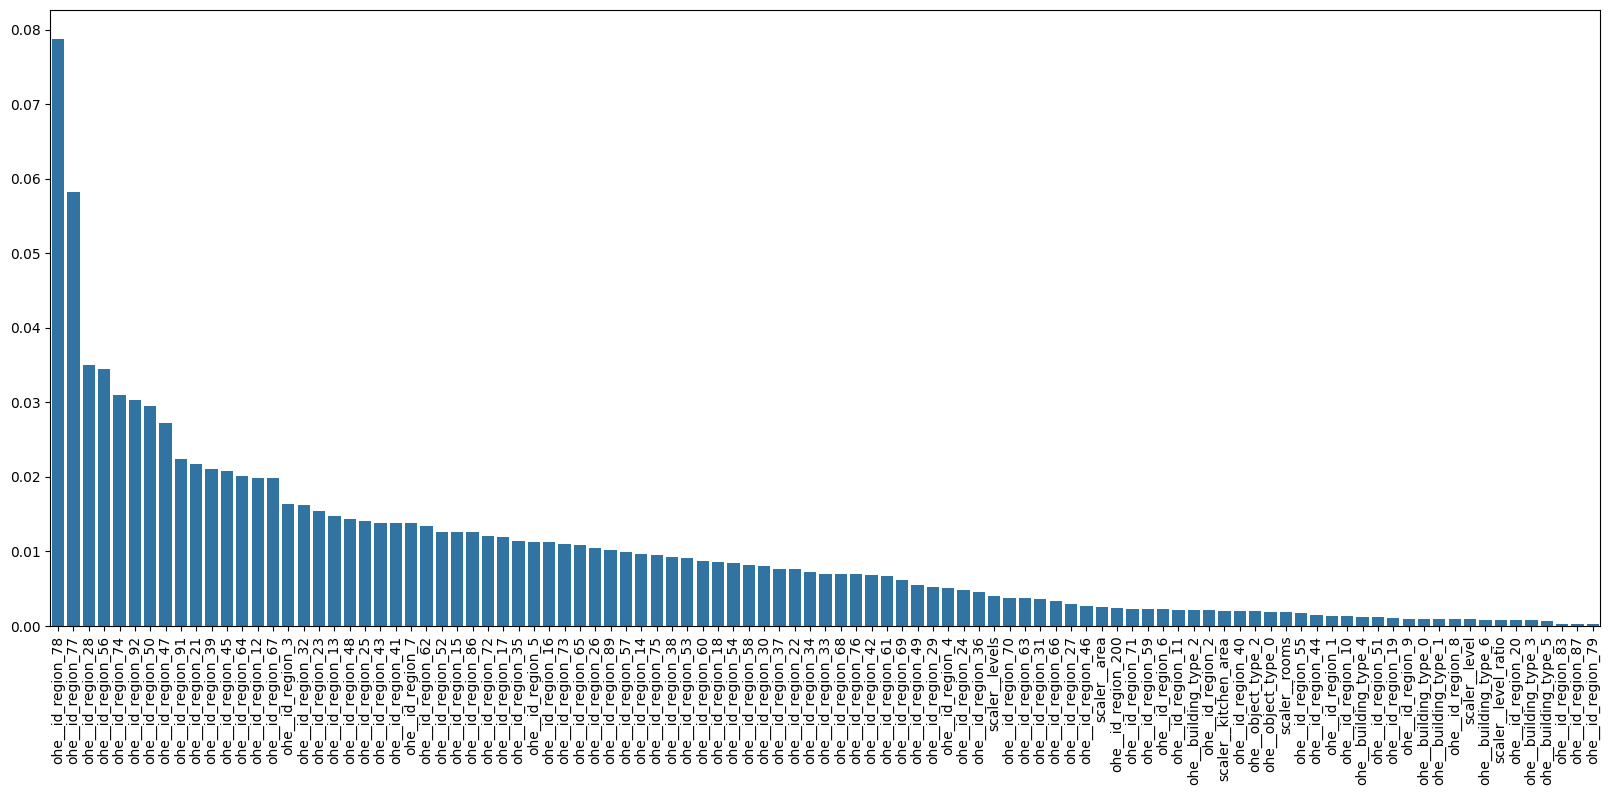

In [73]:
feat_imp = pd.Series(xgbst.feature_importances_, index=X_train_fin.columns).sort_values(ascending=False)

plt.figure(figsize=(20, 8), dpi=100)
sns.barplot(feat_imp);
plt.xticks(rotation=90);

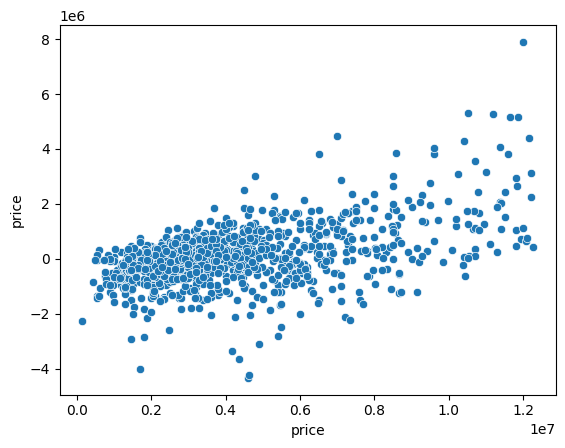

In [74]:
# errors analysis
# we're taking sample
sns.scatterplot(x=y_test_fin[:1000], y=y_test_fin[:1000] - xgb_pred[:1000]);

We see that the errors for some points are very large (ideally, the Y-axis should have zero values).

The error is almost linearly dependent on price, meaning the higher the price, the worse the model performs. This means that this model is not designed to predict prices for very expensive apartments (although we have already removed apartments with very high prices).

We need to save the XGBoost model to use it for further model deployment:

In [75]:
joblib.dump(xgbst, 'XGBoost_model')

print('XGBoost_model saved')

XGBoost_model saved


**5.2 LightGBM**

In [76]:
%%capture

pip install optuna-integration[LightGBM]

In [77]:
# import lightgbm as lgb
# from optuna.integration import LightGBMPruningCallback
# from sklearn.model_selection import train_test_split

# def objective(trial, X, y):
#     params = {
#         'boosting_type': 'gbdt',
#         'max_depth': trial.suggest_int('max_depth', 5, 8),
#         'learning_rate': trial.suggest_float('learning_rate', 0.2, 0.6),
#         'objective': 'regression',
#         'metric': 'mape',
#         'colsample_bytree': trial.suggest_float('colsample_bytree', 0.8, 1),
#         'reg_alpha': trial.suggest_float('reg_alpha', 6, 10),
#         'reg_lambda': trial.suggest_float('reg_lambda', 0.01, 0.03),
#         'random_state': 42,
#         'verbose': -1
#              }
    
#     # we can determine 'num_leaves' through 'max_depth'
#     # params['num_leaves'] = 2 ** params['max_depth']

#     # it is advisable to use cross-validation, but the data volume is very large
#     X_tr, X_val, y_tr, y_val = train_test_split(X, y, test_size=0.2)
#     train_data = lgb.Dataset(X_tr, label=y_tr)
#     val_data = lgb.Dataset(X_val, label=y_val, reference=train_data)

#     # teaching with early_stopping
#     model = lgb.train(params, train_data, num_boost_round=1000,
#                       valid_sets=[val_data], valid_names=['valid_0'],
#                       callbacks=[LightGBMPruningCallback(trial, 'mape'),
#                                  lgb.early_stopping(stopping_rounds=50, verbose=False),
#                                  lgb.log_evaluation(period=0)] # disabling logs
#                      )

#     return model.best_score['valid_0']['mape']


# study = optuna.create_study(direction='minimize', study_name='LightGBM',
#                             pruner=optuna.pruners.MedianPruner(n_startup_trials=10, n_warmup_steps=100))
# study.optimize(lambda trial: objective(trial, X_train_fin, y_train_fin), n_trials=50,
#                n_jobs=-1, show_progress_bar=True)

# lgbm_optuna_score = study.best_value
# lgbm_optuna_params = study.best_params

In [78]:
# lgbm_optuna_params

In [79]:
import lightgbm as lgb
from sklearn.model_selection import train_test_split

params = {'max_depth': 7, 'learning_rate': 0.599238739069755, 'colsample_bytree': 0.9963693792291881,
          'reg_alpha': 6.0209054039114855, 'reg_lambda': 0.016645604333154002}

X_tr, X_val, y_tr, y_val = train_test_split(X_train_fin, y_train_fin, test_size=0.2,
                                            random_state=42)
lgbm = lgb.LGBMRegressor(boosting_type='gbdt', n_estimators=2000, **params)
# we can see the metric in the validation dataset every 100 iterations
lgbm.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], eval_metric='mape',
         callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False),
                    lgb.log_evaluation(period=100)])

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.125755 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1013
[LightGBM] [Info] Number of data points in the train set: 3266686, number of used features: 101
[LightGBM] [Info] Start training from score 4348998.776991
[100]	valid_0's mape: 0.254261	valid_0's l2: 1.3922e+12
[200]	valid_0's mape: 0.248917	valid_0's l2: 1.34613e+12
[300]	valid_0's mape: 0.246056	valid_0's l2: 1.32159e+12
[400]	valid_0's mape: 0.24423	valid_0's l2: 1.3049e+12
[500]	valid_0's mape: 0.243089	valid_0's l2: 1.29378e+12
[600]	valid_0's mape: 0.242071	valid_0's l2: 1.28565e+12
[700]	valid_0's mape: 0.241167	valid_0's l2: 1.27822e+12
[800]	valid_0's mape: 0.240525	valid_0's l2: 1.2724e+12
[900]	valid_0's mape: 0.239782	valid_0's l2: 1.2665e+12
[1000]	valid_0's mape: 0.239165	valid_0's l2: 1.26122e+12
[LightGBM] [Warning

LGBMRegressor(colsample_bytree=0.9963693792291881,
              learning_rate=0.599238739069755, max_depth=7, n_estimators=2000,
              reg_alpha=6.0209054039114855, reg_lambda=0.016645604333154002)

In [80]:
# we explicitly specify the best iteration
lgb_pred = lgbm.predict(X_test_fin, start_iteration=0, num_iteration=lgbm.best_iteration_)

print(lgb_pred[lgb_pred < 0].shape)
print(lgb_pred.min())

(16,)
-853242.9626895376


There are negative values, we need to fix it:

In [81]:
from sklearn.metrics import mean_absolute_percentage_error

median = np.median(lgb_pred[lgb_pred > 0])
lgb_pred = np.where(lgb_pred < 0, median, lgb_pred)

print(lgb_pred[lgb_pred < 0].shape)
print(mean_absolute_percentage_error(y_test_fin, lgb_pred) * 100)

(0,)
23.51607309875243


In [82]:
lgbm.best_iteration_

1999

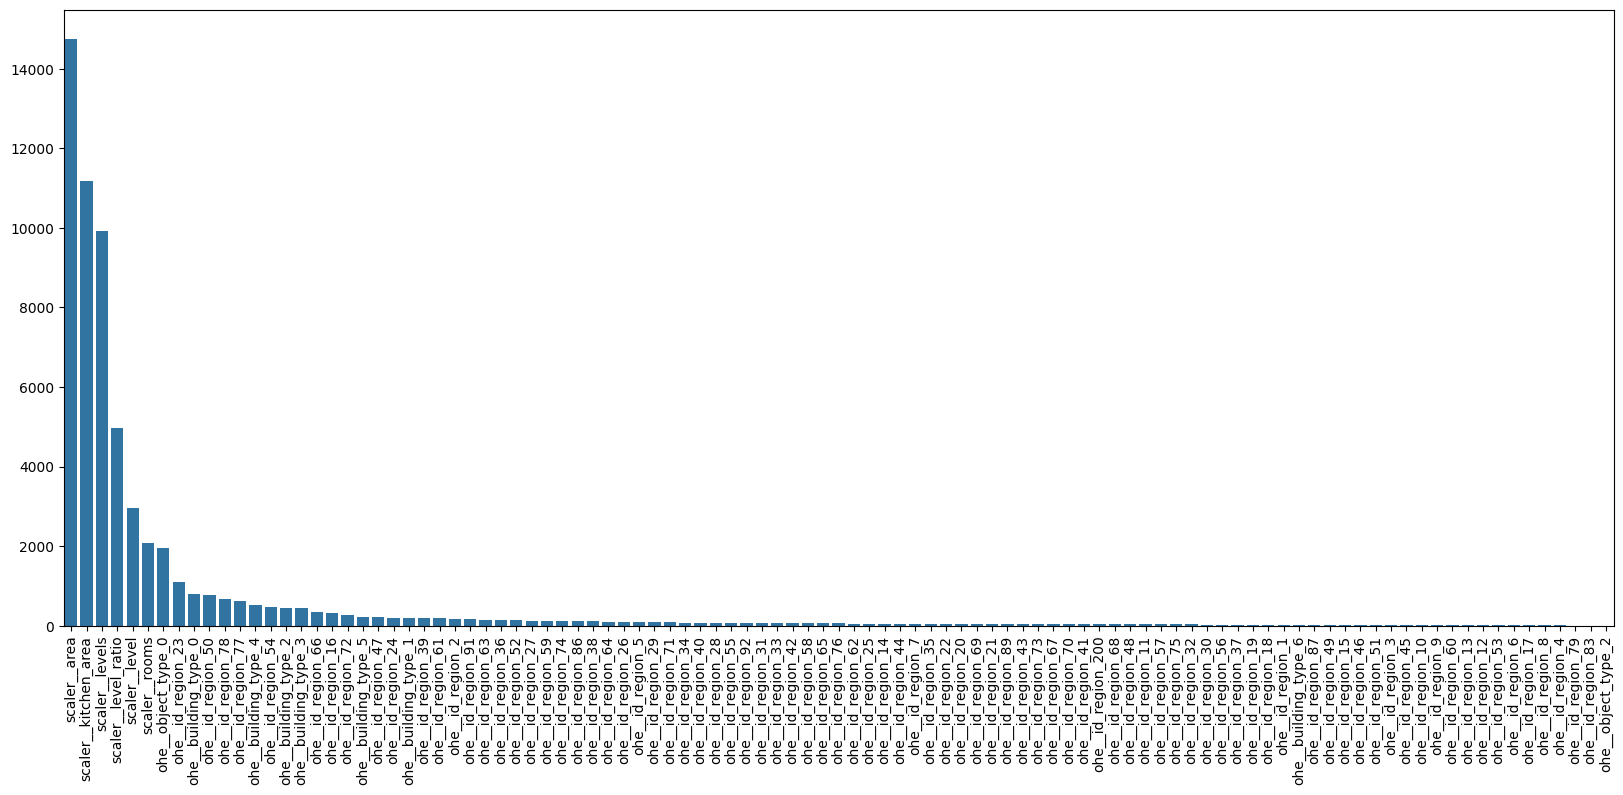

In [83]:
feat_imp = pd.Series(lgbm.feature_importances_, index=X_train_fin.columns).sort_values(ascending=False)

plt.figure(figsize=(20, 8), dpi=100)
sns.barplot(feat_imp);
plt.xticks(rotation=90);

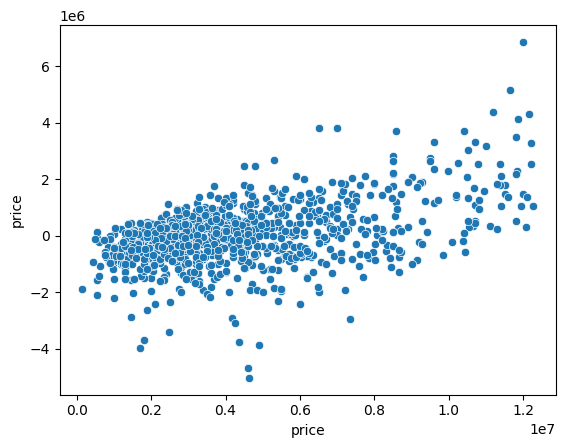

In [84]:
# errors analysis
# we're taking sample
sns.scatterplot(x=y_test_fin[:1000], y=y_test_fin[:1000] - lgb_pred[:1000]);

For LGBM, we see the same picture as for XGBoost. The model is not designed to predict prices for very expensive apartments.

**5.3 Model stacking**

First, we will try to calculate the average value of our predictions.

In [85]:
y_pred_mean = np.array([xgb_pred, lgb_pred]).mean(axis=0)

print(mean_absolute_percentage_error(y_test_fin, y_pred_mean) * 100)

22.849986218466057


We got an intermediate result between the best and worst values - i.e. averaging does not provide improvement

Also we can use StackingRegressor:

In [86]:
# from sklearn.ensemble import StackingRegressor
# from sklearn.linear_model import Ridge
# from sklearn.model_selection import train_test_split
# from xgboost import XGBRegressor
# from lightgbm import LGBMRegressor

# # previously found hyperparameters
# xgb_params = {'max_depth': 9, 'learning_rate': 0.15437133923949717, 'subsample': 0.9162586063529059,
#               'colsample_bytree': 0.8218335931685306, 'reg_alpha': 0.5486978101213894,
#               'reg_lambda': 0.7801262030343257}
# lgb_params = {'max_depth': 7, 'learning_rate': 0.599238739069755, 'colsample_bytree': 0.9963693792291881,
#               'reg_alpha': 6.0209054039114855, 'reg_lambda': 0.016645604333154002}

# # base models - we don't use early_stopping
# base_models = [('xgb', XGBRegressor(objective='reg:absoluteerror', n_estimators=2000,
#                                     eval_metric='mape', **xgb_params)),
#                ('lgbm', lgb.LGBMRegressor(boosting_type='gbdt', n_estimators=2000, **lgb_params))]

# # meta-model
# meta_model = Ridge(alpha=1)
# # cv=3 - 3-fold cross-validation
# # cv='prefit' - it's assumed that all base models have already been trained
# # passthrough=True allows using original features
# stacking_reg = StackingRegressor(estimators=base_models, final_estimator=meta_model,
#                                  cv=3, passthrough=False, n_jobs=-1)

# stacking_reg.fit(X_train_fin, y_train_fin)
# y_pred = stacking_reg.predict(X_test_fin)

# print(mean_absolute_percentage_error(y_test_fin, y_pred) * 100)

With the baseline models' results of 25.32% (XGBoost) and 26.01% (LGBM), stacking gives a result of 25.71%. In this form, it's useless, and with cross-validation, the training time is very long. To potentially improve the quality, we could consider other final models and adjust their hyperparameters. However, we won't cover that here.